Jumlah dataset : (2, 10000)
Jumlah Eigenface : (2, 10000)


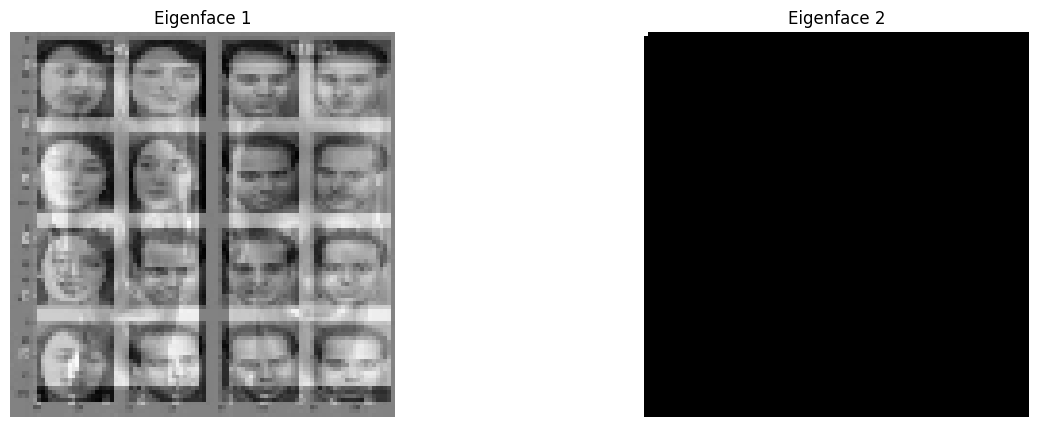

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# LOAD DATASET WAJAH
# ==========================================

path_dataset = "datawajah"

images = []
image_shape = None

if not os.path.exists(path_dataset):
    print("Folder dataset tidak ditemukan!")
    exit()

for filename in os.listdir(path_dataset):

    img_path = os.path.join(path_dataset, filename)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    img = cv2.resize(img, (100, 100))

    image_shape = img.shape

    img_vector = img.flatten()

    images.append(img_vector)

X = np.array(images)

print("Jumlah dataset :", X.shape)

# ==========================================
# HITUNG MEAN FACE
# ==========================================

mean_face = np.mean(X, axis=0)

A = X - mean_face

# ==========================================
# SVD
# ==========================================

U, S, VT = np.linalg.svd(A, full_matrices=False)

num_eigenfaces = min(5, len(images))


eigenfaces = VT[:num_eigenfaces]

print("Jumlah Eigenface :", eigenfaces.shape)

# ==========================================
# TAMPILKAN EIGENFACE
# ==========================================

fig, axes = plt.subplots(1, num_eigenfaces, figsize=(15, 5))

for i in range(num_eigenfaces):

    eigenface = eigenfaces[i].reshape(image_shape)

    axes[i].imshow(eigenface, cmap='gray')
    axes[i].set_title(f"Eigenface {i+1}")
    axes[i].axis("off")

plt.show()